```
# Naujoks 1996 prompt-redeposition example
#
# Author: Abdourahmane Diaw
# Copyright (C) 2023-2026 Abdourahmane Diaw, Oak Ridge National Laboratory
# License: GPL-3.0-or-later. Full text in the OpenEdge LICENSE file.
```

# Naujoks 1996 (Nucl. Fusion 36 671) — Fig. 7: prompt redeposition of W

Fraction $r$ of sputtered W redeposited within the first gyration after
ionization, vs $p=\lambda_{\rm ion}/\rho_{\rm gyro}$. $T_e=20$ eV, $B=2$ T,
$\alpha=2°$, flat W target at $z=0$, periodic laterals.
Runs: `./run_naujoks.sh [a0|a2|b|all]`.

| case | setup | figure |
|---|---|---|
| `a0` | $\alpha=0$, single-ioniz, no E | 7(a) check vs eq. (3) |
| `a2` | $\alpha=2°$, single-ioniz, no E | 7(a) |
| `A` | $\alpha=2°$, single-ioniz, sheath E | 7(b) A |
| `B` | $\alpha=2°$, multi-ioniz, no E | 7(b) B |
| `C` | $\alpha=2°$, multi-ioniz, sheath E | 7(b) C |

In [1]:
import glob, os, re, math, collections
import numpy as np
import matplotlib.pyplot as plt

QE=1.602176634e-19
M_W=3.077624296e-25                 # W+ mass as in plasma.species (184*m_p)
B_T=2.0; DT=5e-9
OMEGA=QE*B_T/M_W                    # W+ gyrofrequency at 2 T
TGYRO=2*math.pi/OMEGA               # ~6.0 us
WSTEP=TGYRO/DT                      # prompt window in steps
print(f"W+ at {B_T} T: omega={OMEGA:.3e} rad/s, gyroperiod={TGYRO*1e6:.2f} us "
      f"= {WSTEP:.0f} steps prompt window")

W+ at 2.0 T: omega=1.041e+06 rad/s, gyroperiod=6.03 us = 1207 steps prompt window


## Classification

One pass per dump: birth, first ionization, death, last $z$. Prompt = dies
at the target within one W⁺ gyroperiod of first ionization. `wplus_only`
counts only atoms landing still as W⁺ (ERO's curve-B bookkeeping).

In [2]:
def scan_dump(path):
    born={}; tion={}; lastk={}; lastz={}; lastt={}
    cur=0; iid=ity=iz=None; ia=False; ts=False
    for line in open(path):
        if line.startswith("ITEM: TIMESTEP"): ia=False; ts=True; continue
        if ts: cur=int(line.split()[0]); ts=False; continue
        if line.startswith("ITEM: ATOMS"):
            if iid is None:
                h=line.split()[2:]; iid=h.index("id"); ity=h.index("type"); iz=h.index("z")
            ia=True; continue
        if line.startswith("ITEM:"): ia=False; continue
        if ia:
            p=line.split()
            if len(p)>max(iid,ity,iz):
                pid=int(p[iid])
                if pid not in born: born[pid]=cur
                if pid not in tion and int(p[ity])>1: tion[pid]=cur
                lastk[pid]=cur; lastz[pid]=float(p[iz]); lastt[pid]=int(p[ity])
    return born,tion,lastk,lastz,lastt,cur

def prompt_r(path, wplus_only=False):
    born,tion,lastk,lastz,lastt,last=scan_dump(path)
    prompt=nonp=0
    for pid,b in born.items():
        died=lastk[pid]<last
        if pid in tion:
            ti=tion[pid]
            if ti>last-WSTEP: continue
            if (died and lastz[pid]<0.01 and lastk[pid]-ti<=WSTEP
                and (not wplus_only or lastt[pid]==2)): prompt+=1
            else: nonp+=1
        elif died and lastz[pid]<0.01:
            prompt+=1    # landed between dumps, was W+
        elif died and lastz[pid]>0.01:
            nonp+=1
    n=prompt+nonp
    return (prompt/n if n else np.nan), prompt, nonp

def tau_meas(path):
    born,tion,lastk,lastz,lastt,last=scan_dump(path)
    ts=[(tion[p]-born[p])*DT for p in tion if tion[p]>born[p]]
    return np.mean(ts) if ts else np.nan

# <sigma v> from the cadence-1 diag dump
for CAL_DUMP,CAL_NE in (("state/redepo.nj_diag_ne1.06e19",1.06e19),
                        ("state/redepo.nj_off_ne5.3e18",5.3e18)):
    if os.path.exists(CAL_DUMP): break
tau=tau_meas(CAL_DUMP)
SIGV=1.0/(CAL_NE*tau)
print(f"tau_ion({CAL_NE:.1e})={tau*1e6:.3f} us -> <sigma v>={SIGV:.3e} m^3/s  [{CAL_DUMP}]")

R={}
for f in sorted(glob.glob("state/redepo.nj_*")):
    m=re.match(r".*redepo\.nj_(\w+?)_ne([0-9.e+-]+)$",f)
    if not m: continue
    case,ne=m.group(1),float(m.group(2))
    if case=="diag": continue
    r,npr,nn=prompt_r(f)
    R[(case,ne)]=dict(case=case,ne=ne,p=OMEGA/(ne*SIGV),r=r,n=npr+nn)
    if case=="B":
        r2,npr2,nn2=prompt_r(f,wplus_only=True)
        R[("Bp",ne)]=dict(case="Bp",ne=ne,p=OMEGA/(ne*SIGV),r=r2,n=npr2+nn2)
for case in sorted({v["case"] for v in R.values()}):
    rows=sorted([v for k,v in R.items() if v["case"]==case],key=lambda v:v["p"])
    print(f"\n {case:13}: "+"  ".join(f"p={v['p']:5.2f}:r={v['r']:.3f}" for v in rows))

tau_ion(1.1e+19)=0.391 us -> <sigma v>=2.412e-13 m^3/s  [state/redepo.nj_diag_ne1.06e19]



 A            : p= 0.04:r=0.993  p= 0.08:r=0.982  p= 0.17:r=0.961  p= 0.41:r=0.927  p= 0.81:r=0.839  p= 1.63:r=0.702  p= 3.32:r=0.484  p= 4.91:r=0.377

 B            : p= 0.04:r=0.636  p= 0.08:r=0.586  p= 0.17:r=0.534  p= 0.41:r=0.475  p= 0.81:r=0.457  p= 1.63:r=0.400  p= 3.32:r=0.291  p= 4.91:r=0.227

 Bp           : p= 0.04:r=0.009  p= 0.08:r=0.019  p= 0.17:r=0.062  p= 0.41:r=0.202  p= 0.81:r=0.321  p= 1.63:r=0.345  p= 3.32:r=0.271  p= 4.91:r=0.215

 C            : p= 0.04:r=0.915  p= 0.08:r=0.870  p= 0.17:r=0.828  p= 0.41:r=0.778  p= 0.81:r=0.739  p= 1.63:r=0.629  p= 3.32:r=0.475  p= 4.91:r=0.396

 a0           : p= 0.04:r=0.991  p= 0.08:r=0.982  p= 0.17:r=0.955  p= 0.41:r=0.845  p= 0.81:r=0.703  p= 1.63:r=0.499  p= 3.32:r=0.319  p= 4.91:r=0.254

 a2           : p= 0.04:r=0.957  p= 0.08:r=0.949  p= 0.17:r=0.923  p= 0.41:r=0.832  p= 0.81:r=0.695  p= 1.63:r=0.509  p= 3.32:r=0.332  p= 4.91:r=0.253


## Analytic curves

Eq. (2): fixed ionization length. Eq. (3): eq. (2) averaged over the
exponential length distribution, $\langle r\rangle=\int_0^\infty
r_{(2)}(pu)\,e^{-u}du$.

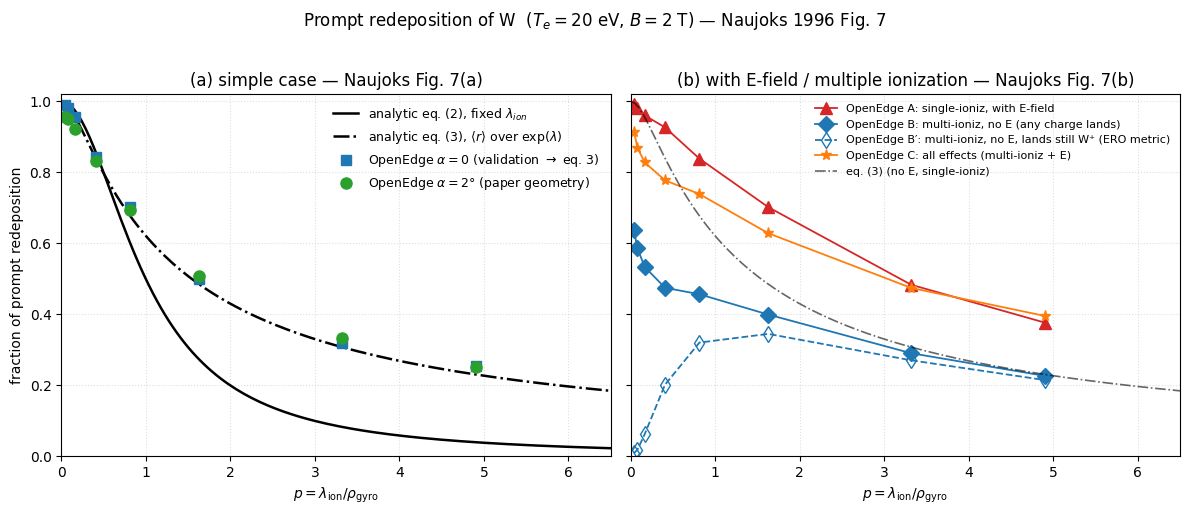

In [3]:
def r_eq2(p):
    if p==1.0: return 0.5
    s=1.0 if p<1 else -1.0
    return 0.5*(1+s*(1+4*p*p/(1-p*p)**2)**-0.5)

U=np.linspace(0,40,4001); EXPU=np.exp(-U)
def r_eq3(p):
    # <r> = int r_eq2(p*u) e^-u du   (u = x/p: exponential always resolved)
    if p<=0: return 1.0
    return (np.trapezoid if hasattr(np,'trapezoid') else np.trapz)(np.array([r_eq2(p*u) for u in U])*EXPU,U)

pp=np.linspace(0.01,6.5,140)
eq2=[r_eq2(p) for p in pp]; eq3=[r_eq3(p) for p in pp]

def rows_of(case):
    return sorted([v for k,v in R.items() if v["case"]==case],key=lambda v:v["p"])

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5),sharey=True)
# --- (a): simple case vs analytics ---
ax1.plot(pp,eq2,"k-",lw=1.8,label="analytic eq. (2), fixed $\\lambda_{ion}$")
ax1.plot(pp,eq3,"k-.",lw=1.8,label="analytic eq. (3), $\\langle r\\rangle$ over exp($\\lambda$)")
for case,c,mk,ms,lab in (
    ("a0","C0","s",7,"$\\alpha=0$ (validation $\\to$ eq. 3)"),
    ("a2","C2","o",8,"$\\alpha=2°$ (paper geometry)")):
    rows=rows_of(case)
    if rows:
        ax1.plot([v["p"] for v in rows],[v["r"] for v in rows],mk,ms=ms,color=c,
                 label="OpenEdge "+lab)
ax1.set_title("(a) simple case — Naujoks Fig. 7(a)")
ax1.set_xlabel(r"$p=\lambda_{\rm ion}/\rho_{\rm gyro}$")
ax1.set_ylabel("fraction of prompt redeposition")
ax1.set_xlim(0,6.5); ax1.set_ylim(0,1.02); ax1.grid(ls=":",alpha=0.4)
ax1.legend(frameon=False,fontsize=9)
# --- (b): all effects (nemit 1 + fixed sheath phi blend) ---
styles={"A":("C3","^","-","A: single-ioniz, with E-field"),
        "B":("C0","D","-","B: multi-ioniz, no E (any charge lands)"),
        "Bp":("C0","d","--","B′: multi-ioniz, no E, lands still W⁺ (ERO metric)"),
        "C":("C1","*","-","C: all effects (multi-ioniz + E)")}
for case,(c,mk,ls,lab) in styles.items():
    rows=rows_of(case)
    if rows:
        ax2.plot([v["p"] for v in rows],[v["r"] for v in rows],ls,marker=mk,ms=8,
                 color=c,lw=1.3,mfc="none" if case=="Bp" else c,
                 label="OpenEdge "+lab)
ax2.plot(pp,eq3,"k-.",lw=1.2,alpha=0.6,label="eq. (3) (no E, single-ioniz)")
ax2.set_title("(b) with E-field / multiple ionization — Naujoks Fig. 7(b)")
ax2.set_xlabel(r"$p=\lambda_{\rm ion}/\rho_{\rm gyro}$")
ax2.set_xlim(0,6.5); ax2.grid(ls=":",alpha=0.4); ax2.legend(frameon=False,fontsize=8)
fig.suptitle(r"Prompt redeposition of W  ($T_e=20$ eV, $B=2$ T) — Naujoks 1996 Fig. 7",y=1.02)
plt.tight_layout(); plt.show()

### Notes

- The $\alpha=0$ run matches eq. (3) at all densities. The $\alpha=2°$
  points sit ~0.03 lower at small $p$: grazing ions with $v_\parallel>0$
  escape along the tilted field.
- Panel (b) vs the paper: A ≈ 1 for $p<1$ as in ERO; B′ (W⁺-only landings)
  collapses at small $p$ and peaks near $p\sim1$ like ERO's curve B; C lies
  in between. OpenEdge sits above ERO at larger $p$: distributed MPS/DS
  field vs ERO's $\Delta z=e\rho$ slab, and ADAS vs 1996 rate data.
- Runs need `nemit 1` (emit `nevery>1` pre-advances atoms past the
  near-surface ionization window) and the sheath φ-blend fix in
  `sheath_models.cpp` (2026-07-23).
- ~1500 particles per point (±0.01).